## Milestone 3
### Feature Engineering
### Yiscah Mark


In [1]:
import pandas as pd

# The unique ID from your shared URL
file_id = '1Pb92AOUPCUaM8bC8m83pO1S9QZBwmD1c'
direct_link = f'https://drive.google.com/uc?id={file_id}'

# Load the dataset directly into a DataFrame
try:
    df = pd.read_csv(direct_link)
    print("Connection successful. Dataset loaded.")
    print(df.head())
except Exception as e:
    print(f"Error connecting to the file: {e}")
    print("Ensure the Google Drive link is set to 'Anyone with the link can view'.")

Connection successful. Dataset loaded.
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


Displaying the data. Throughout I keep displaying the first five rows to see the changes.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np

display(df.head())


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Checking the shape, the datatype in each column, the column names...

In [3]:
# Check the initial shape and info
print(df.shape)
df.head()
df.info()
df.describe()
df.isna()

(4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4335,False,False,False,False,False,False,False,False
4336,False,False,False,False,False,False,False,False
4337,False,False,False,False,False,False,False,False
4338,False,False,False,False,False,False,False,False


When I counted the fuel types in the fuel column some of the petrol fuel were spelled with a capital P and some with a lowercase p, therefore I standardized the text to lowercase. I also reprinted the revised totals and I see that the electric and lpg have such low counts that it just acts as noise.

In [4]:
# 1. Standardize the text to lowercase BEFORE encoding
df['fuel'] = df['fuel'].str.lower()

# 2. Re-run the encoding
# We will also drop 'electric' manually or let it be handled by drop_first
df = pd.get_dummies(df, columns=['fuel'], drop_first=True, dtype=int)

# 3. Check the counts again
fuel_cols = [col for col in df.columns if col.startswith('fuel')]
print(df[fuel_cols].sum())

fuel_diesel      2153
fuel_electric       1
fuel_lpg           23
fuel_petrol      2123
dtype: int64


I removed the electric and LPG columns, and then rechecked the new totals.


In [5]:
# Filter the dataframe to keep only Diesel and Petrol based on dummy variables
# This removes the 1 Electric and 23 LPG rows
# Keep rows where fuel_electric is 0 AND fuel_lpg is 0.
df = df[(df['fuel_electric'] == 0) & (df['fuel_lpg'] == 0)]

# The original 'fuel' column no longer exists, so standardizing casing is not applicable.
# Verify the clean counts by summing the dummy variables
print("Remaining fuel type counts:")
print(f"Diesel: {df['fuel_diesel'].sum()}")
print(f"Petrol: {df['fuel_petrol'].sum()}")
print(f"Electric: {df['fuel_electric'].sum()}")
print(f"LPG: {df['fuel_lpg'].sum()}")

Remaining fuel type counts:
Diesel: 2153
Petrol: 2123
Electric: 0
LPG: 0


In [6]:
df.drop(columns=['fuel_electric', 'fuel_lpg'], inplace=True)
display(df.head())

,name,year,selling_price,km_driven,seller_type,transmission,owner,fuel_diesel,fuel_petrol
0,Maruti 800 AC,2007,60000,70000,Individual,Manual,First Owner,0,1
1,Maruti Wagon R LXI Minor,2007,135000,50000,Individual,Manual,First Owner,0,1
2,Hyundai Verna 1.6 SX,2012,600000,100000,Individual,Manual,First Owner,1,0
3,Datsun RediGO T Option,2017,250000,46000,Individual,Manual,First Owner,0,1
4,Honda Amaze VX i-DTEC,2014,450000,141000,Individual,Manual,Second Owner,1,0


There are too many unique names of cars. This is too noizy for the model. The company is enough to get a picture and predict. I rewrote a new name column which just pulls out the first word of each name, which is the company.

I then printed all the unique names.

In [7]:
# Extract the first word from the 'name' column and reassign it to replace the original
df['name'] = df['name'].str.split().str[0]

# Verify the change
print(df['name'].unique())
display(df.head())

['Maruti' 'Hyundai' 'Datsun' 'Honda' 'Tata' 'Chevrolet' 'Toyota' 'Jaguar'
 'Mercedes-Benz' 'Audi' 'Skoda' 'Jeep' 'BMW' 'Mahindra' 'Ford' 'Nissan'
 'Renault' 'Fiat' 'Volkswagen' 'Volvo' 'Mitsubishi' 'Land' 'Daewoo' 'MG'
 'Force' 'Isuzu' 'OpelCorsa' 'Ambassador' 'Kia']


,name,year,selling_price,km_driven,seller_type,transmission,owner,fuel_diesel,fuel_petrol
0,Maruti,2007,60000,70000,Individual,Manual,First Owner,0,1
1,Maruti,2007,135000,50000,Individual,Manual,First Owner,0,1
2,Hyundai,2012,600000,100000,Individual,Manual,First Owner,1,0
3,Datsun,2017,250000,46000,Individual,Manual,First Owner,0,1
4,Honda,2014,450000,141000,Individual,Manual,Second Owner,1,0


Here I printed the unique car company names along with the counts.

In [8]:
print("Number of unique car brands:", df['name'].nunique())
print("car brands:\n", df['name'].value_counts().head(29))

Number of unique car brands: 29
car brands:
 Maruti           1266
Hyundai           813
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            205
Chevrolet         187
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Fiat               37
Datsun             37
Mercedes-Benz      35
Jaguar              6
Mitsubishi          6
Land                5
Volvo               4
Ambassador          4
Jeep                3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: name, dtype: int64


Some conpanies appear very rearly. In a way they act as noise and mess up the model. On the other hand we lose information. I decided to put the threshold at 10. Any car company that appears less that 10 times is removed.

In [9]:
# Get the counts of each car brand
brand_counts = df['name'].value_counts()

# Identify brands with less than 10 occurrences
rare_brands = brand_counts[brand_counts < 10].index

# Filter the DataFrame to keep only brands with 10 or more occurrences
df = df[~df['name'].isin(rare_brands)]

print(f"Number of car brands before filtering: {len(brand_counts)}")
print(f"Number of car brands after filtering: {df['name'].nunique()}")
print("Remaining car brands (top 20):\n", df['name'].value_counts().head(20))

display(df.head())

Number of car brands before filtering: 29
Number of car brands after filtering: 17
Remaining car brands (top 20):
 Maruti           1266
Hyundai           813
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            205
Chevrolet         187
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Datsun             37
Fiat               37
Mercedes-Benz      35
Name: name, dtype: int64


,name,year,selling_price,km_driven,seller_type,transmission,owner,fuel_diesel,fuel_petrol
0,Maruti,2007,60000,70000,Individual,Manual,First Owner,0,1
1,Maruti,2007,135000,50000,Individual,Manual,First Owner,0,1
2,Hyundai,2012,600000,100000,Individual,Manual,First Owner,1,0
3,Datsun,2017,250000,46000,Individual,Manual,First Owner,0,1
4,Honda,2014,450000,141000,Individual,Manual,Second Owner,1,0


In [10]:
df = pd.get_dummies(df, columns=['name'], drop_first=True, dtype=int)

I have two numerical columns (year and Kilometers driven). The year only goes to about two thousand and the kilometers goes over 100,000. Since these ranges are so different it can mess up the model. In the next cell I will normalize the figures by making each a number between 0 and 1 so the difference in range doesn't skew everything.I used the min-max scaling in which 0 is the lowest number in ther range and 1 is the highest. I didn't use standard scaling, which scales relative the the standard deviations because i wanted it to be in the same range as the encodded columns.

I am obviously not normalizing my selling price column because it is the target variable.

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Select the columns to normalize
cols_to_fix = ['km_driven', 'year']

# Apply the transformation
df[cols_to_fix] = scaler.fit_transform(df[cols_to_fix])

display(df.head())

,year,selling_price,km_driven,seller_type,transmission,owner,fuel_diesel,fuel_petrol,name_BMW,name_Chevrolet,...,name_Hyundai,name_Mahindra,name_Maruti,name_Mercedes-Benz,name_Nissan,name_Renault,name_Skoda,name_Tata,name_Toyota,name_Volkswagen
0,0.535714,60000,0.086783,Individual,Manual,First Owner,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0.535714,135000,0.061988,Individual,Manual,First Owner,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0.714286,600000,0.123976,Individual,Manual,First Owner,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0.892857,250000,0.057028,Individual,Manual,First Owner,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.785714,450000,0.174807,Individual,Manual,Second Owner,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


I am encoding these categorical data columns so I can feed it into a regression model.

In [12]:
categorical_cols_to_encode = ['seller_type', 'transmission', 'owner']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

display(df.head())
print(f"Shape after encoding: {df.shape}")

,year,selling_price,km_driven,fuel_diesel,fuel_petrol,name_BMW,name_Chevrolet,name_Datsun,name_Fiat,name_Ford,...,name_Tata,name_Toyota,name_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0.535714,60000,0.086783,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1,0.535714,135000,0.061988,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2,0.714286,600000,0.123976,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,0.892857,250000,0.057028,0,1,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0.785714,450000,0.174807,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0


Shape after encoding: (4280, 28)


I am examining the rest of the encoded categories to see if I should drop anything.

In [13]:

print("Current columns in DataFrame:")
print(df.columns.tolist())

print("\n--- Examining Categorical Feature Distributions (after one-hot encoding) ---")

# Seller Type
seller_type_dummies = [col for col in df.columns if col.startswith('seller_type_')]
if seller_type_dummies:
    print("\nSeller Type Distribution (from dummy variables):")
    display(df[seller_type_dummies].sum().rename(lambda x: x.replace('seller_type_', '')))
else:
    print("\nNo seller_type dummy columns found. Please verify preprocessing steps.")

# Transmission Type
transmission_dummies = [col for col in df.columns if col.startswith('transmission_')]
if transmission_dummies:
    print("\nTransmission Type Distribution (from dummy variables):")
    display(df[transmission_dummies].sum().rename(lambda x: x.replace('transmission_', '')))
else:
    print("\nNo transmission_type dummy columns found. Please verify preprocessing steps.")

# Owner Type
owner_dummies = [col for col in df.columns if col.startswith('owner_')]
if owner_dummies:
    print("\nOwner Type Distribution (from dummy variables):")
    display(df[owner_dummies].sum().rename(lambda x: x.replace('owner_', '')))
else:
    print("\nNo owner_type dummy columns found. Please verify preprocessing steps.")

# Car Brand (Name) Distribution
name_dummies = [col for col in df.columns if col.startswith('name_')]
if name_dummies:
    print("\nCar Brand (Name) Distribution (from dummy variables):")
    display(df[name_dummies].sum().sort_values(ascending=False).rename(lambda x: x.replace('name_', '')))
else:
    print("\nNo brand (name) dummy columns found. Please verify the encoding step in Cell 10.")

Current columns in DataFrame:
['year', 'selling_price', 'km_driven', 'fuel_diesel', 'fuel_petrol', 'name_BMW', 'name_Chevrolet', 'name_Datsun', 'name_Fiat', 'name_Ford', 'name_Honda', 'name_Hyundai', 'name_Mahindra', 'name_Maruti', 'name_Mercedes-Benz', 'name_Nissan', 'name_Renault', 'name_Skoda', 'name_Tata', 'name_Toyota', 'name_Volkswagen', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

--- Examining Categorical Feature Distributions (after one-hot encoding) ---

Seller Type Distribution (from dummy variables):


Individual          3196
Trustmark Dealer     102
dtype: int64


Transmission Type Distribution (from dummy variables):


Manual    3851
dtype: int64


Owner Type Distribution (from dummy variables):


Fourth & Above Owner      78
Second Owner            1084
Test Drive Car            17
Third Owner              300
dtype: int64


Car Brand (Name) Distribution (from dummy variables):


Maruti           1266
Hyundai           813
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            205
Chevrolet         187
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
BMW                39
Datsun             37
Fiat               37
Mercedes-Benz      35
dtype: int64

#### Everything looks within range. I will leave it. Remember, that the first columns were dropped. Because we can get the information based on the count of the rest of the categories.

#### Since most of the cars are priced regularly and we have a few ouliers that are totally out of range, I will perform log transformation on my price column. This "shows" the model that predicting 5,000 dollars off on a  25,000 dollar car is a lot worse than oon a $100,000 car. The log transformation normalizes the selling price in this way.

In [14]:
# Apply the log transformation
df['price_log'] = np.log(df['selling_price'])

# Compare the skewness (Optional check)
# print(f"Original Skew: {df['selling_price'].skew()}") # This line will also cause an error if selling_price is dropped
print(f"Log-Transformed Skew: {df['price_log'].skew()}")

display(df.head())

Log-Transformed Skew: 0.0379755114523225


,year,selling_price,km_driven,fuel_diesel,fuel_petrol,name_BMW,name_Chevrolet,name_Datsun,name_Fiat,name_Ford,...,name_Toyota,name_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,price_log
0,0.535714,60000,0.086783,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,11.002100
1,0.535714,135000,0.061988,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,11.813030
2,0.714286,600000,0.123976,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,13.304685
3,0.892857,250000,0.057028,0,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,12.429216
4,0.785714,450000,0.174807,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,13.017003


I didn't want to one-hot encode the names column because I didn't like how so many names that mean something just became a series of ones and zeros. The only way to feed it to a regression model is if it is numerical so here it is. when it came to the actual model, I realized that the names are just noise because there are too many of them.

I am dropping the original price column so we don't get confused.

In [15]:
cols_to_drop = ['selling_price']

# Drop them permanently
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

display(df.head())

,year,km_driven,fuel_diesel,fuel_petrol,name_BMW,name_Chevrolet,name_Datsun,name_Fiat,name_Ford,name_Honda,...,name_Toyota,name_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,price_log
0,0.535714,0.086783,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,11.002100
1,0.535714,0.061988,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,11.813030
2,0.714286,0.123976,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,13.304685
3,0.892857,0.057028,0,1,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,12.429216
4,0.785714,0.174807,1,0,0,0,0,0,0,1,...,0,0,1,0,1,0,1,0,0,13.017003


I was going to make the kilometers driven into bins, like split into categories. I didn't since I normalized it and it works well as a continuous number.

This is the last step to prepare for regression, by splitting the features and the target variable into x and y.

In [16]:
X = df.drop('price_log', axis=1)
y = df['price_log']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

display(X.head())
display(y.head())

Shape of X (features): (4280, 27)
Shape of y (target): (4280,)


,year,km_driven,fuel_diesel,fuel_petrol,name_BMW,name_Chevrolet,name_Datsun,name_Fiat,name_Ford,name_Honda,...,name_Tata,name_Toyota,name_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0.535714,0.086783,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1,0.535714,0.061988,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2,0.714286,0.123976,1,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,0.892857,0.057028,0,1,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0.785714,0.174807,1,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,1,0,0


0    11.002100
1    11.813030
2    13.304685
3    12.429216
4    13.017003
Name: price_log, dtype: float64

In [17]:
# 1. Drop the columns you don't want as features
# We include 'selling_price' because we are using 'price_log' as the target
# We include 'name' if it still exists
cols_to_drop = ['selling_price', 'name'] 
X = df.drop([col for col in cols_to_drop if col in df.columns], axis=1)

# Ensure 'price_log' is NOT in X, as it is our target
if 'price_log' in X.columns:
    X = X.drop('price_log', axis=1)

# 2. Define Target
y = df['price_log']

# 3. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features in X:", X.columns.tolist())

Features in X: ['year', 'km_driven', 'fuel_diesel', 'fuel_petrol', 'name_BMW', 'name_Chevrolet', 'name_Datsun', 'name_Fiat', 'name_Ford', 'name_Honda', 'name_Hyundai', 'name_Mahindra', 'name_Maruti', 'name_Mercedes-Benz', 'name_Nissan', 'name_Renault', 'name_Skoda', 'name_Tata', 'name_Toyota', 'name_Volkswagen', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


### MILESTONE 4
### Build a Model

#### I am starting out with a basic linear regression model to predict the car prices. I have to import the correct models, train the model and calculate the metrics to see how accurately the model performs.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Initialize and train the baseline model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 2. Make predictions on the test set (still in log scale)
y_pred_log = baseline_model.predict(X_test)

# 3. Calculate metrics on the Log Scale
baseline_mae_log = mean_absolute_error(y_test, y_pred_log)
baseline_r2 = r2_score(y_test, y_pred_log)

# 4. Convert back to actual price for real-world interpretation
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_log)
baseline_mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

# 5. Print the results
print("--- Baseline Linear Regression Results ---")
print(f"R² Score: {baseline_r2:.4f}")
print(f"Mean Absolute Error (Log Scale): {baseline_mae_log:.4f}")
print(f"Mean Absolute Error (Actual Price): {baseline_mae_actual:.2f}")

--- Baseline Linear Regression Results ---
R² Score: 0.7850
Mean Absolute Error (Log Scale): 0.2931
Mean Absolute Error (Actual Price): 138941.20


#### Moving towards a little more of a complex model, the random forest model.

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Example of a more complex model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred_log = rf_model.predict(X_test)
print(f"Random Forest R-squared: {r2_score(y_test, rf_pred_log):.4f}")

Random Forest R-squared: 0.7988


#### The Random forest was a little more accurate than the linear regression. I am using the RandomizedSearchCV to find the optimal parameters to use in the random forest model with my dataset.

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Now the model will be recognized
rf = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['auto', 'sqrt']
}

# Proceed with Randomized Search
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, 
                               n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fit the model (Ensure X_train and y_train are defined in previous cells)
rf_random.fit(X_train, y_train)



Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=1)

#### In the cell below, First, the best model is extracted using the .best_estimator_ with the best parameters: .best_params_. Finally I run the model and make predictions on the dataset. The next step is to calculate the metrics and evaluate the model's performance. The price is converted back to the original currency to clearly interpret it.

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Extract the best model from the search
best_model = rf_random.best_estimator_
print(f"Best Parameters: {rf_random.best_params_}")

# 2. Make predictions using the test set
y_pred = best_model.predict(X_test)

# 3. Calculate evaluation metrics
# Since we used price_log, we are calculating accuracy on the log scale
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (on log scale): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# 4. Optional: Convert back to original currency prices to see the real error
y_test_original = np.exp(y_test)
y_pred_original = np.exp(y_pred)
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print(f"Mean Absolute Error (in actual price): {mae_original:.2f}")

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Mean Absolute Error (on log scale): 0.2498
R² Score: 0.8197
Mean Absolute Error (in actual price): 116726.49


#### The random forest model is sometimes referred to as the Black-box. There is no pattern that the model follows to learn and predict within the dataset. I will print out a bar chart, as well as the exact printed value of the importance of each feature on the prediction to see if it makes logical sense and to see that the model is learning correctly.

In [22]:

# Get feature importances from the best model
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top 10 features
print(feature_importance_df.head(10))


                   Feature  Importance
0                     year    0.399048
1                km_driven    0.136022
22     transmission_Manual    0.102711
2              fuel_diesel    0.066707
3              fuel_petrol    0.059880
17               name_Tata    0.036032
20  seller_type_Individual    0.028732
18             name_Toyota    0.022082
24      owner_Second Owner    0.018453
12             name_Maruti    0.016613


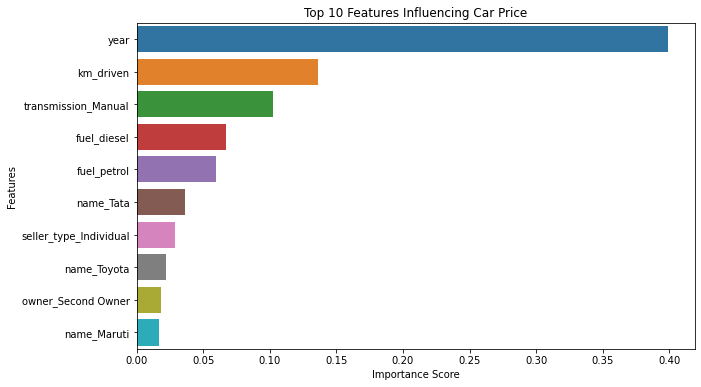

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Now run the plotting code
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Features Influencing Car Price')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### It is hard to read and understand the importance of each sub column , since most of the columns were encoded. In the following cell the importance of each column by parent column is shown.

In [24]:
# Create a mapping of the original categories
groups = {
    'Fuel Type': ['fuel_diesel', 'fuel_petrol', 'fuel_LPG', 'fuel_Electric'],
    'Seller Type': ['seller_type_Individual', 'seller_type_Trustmark Dealer'],
    'Owner History': ['owner_Second Owner', 'owner_Third Owner', 'owner_Fourth & Above Owner', 'owner_Test Drive Car'],
    'Transmission': ['transmission_Manual'],
    'Usage (KM)': ['km_driven'],
    'Age (Year)': ['year'],
    'Brand': [col for col in X.columns if col.startswith('name_')]
}

# Sum the importance scores for each group
grouped_importance = {}
for group_name, cols in groups.items():
    # Filters the feature_importance_df for columns belonging to the current group
    importance_sum = feature_importance_df[feature_importance_df['Feature'].isin(cols)]['Importance'].sum()
    grouped_importance[group_name] = importance_sum

# Convert to DataFrame and sort for the final report
clean_importance_df = pd.DataFrame(list(grouped_importance.items()), columns=['Category', 'Total Importance'])
clean_importance_df = clean_importance_df.sort_values(by='Total Importance', ascending=False)

# Display the aggregated impact of each feature category
print(clean_importance_df)

        Category  Total Importance
5     Age (Year)          0.399048
6          Brand          0.161694
4     Usage (KM)          0.136022
0      Fuel Type          0.126587
3   Transmission          0.102711
2  Owner History          0.038360
1    Seller Type          0.035578


#### This graph shows visual exactly how far the predictions were from the real values. We can see that it seems like the model was on target for the lower more averaged priced cars. The predictions are further from the true value when the cars get more expensive.

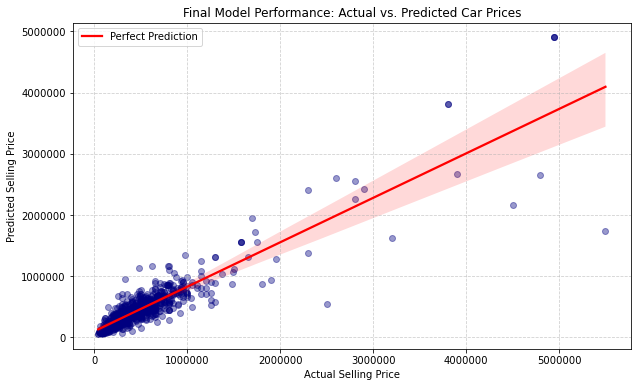

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert log prices back to actual currency for a more readable plot
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

plt.figure(figsize=(10, 6))

# Plotting the regression results
sns.regplot(x=y_test_actual, y=y_pred_actual, 
            scatter_kws={'alpha':0.4, 'color':'navy'}, 
            line_kws={'color':'red', 'label':'Perfect Prediction'})

plt.title('Final Model Performance: Actual vs. Predicted Car Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Formatting axes to avoid scientific notation
plt.ticklabel_format(style='plain', axis='both')
plt.show()

#### This is a list of the top 10 cars with the biggest error. We want to see where the model is slipping the most. The suspected issue is confirmed. The model predicts very poorly on very luxury high-end, expensive cars. This makes sense because often these cars are way out of range of cars with the same features as them. Also, the features such as brand prestige and all-wheel drive, which may raise the car's price dramatically, are not included in this dataset. 
#### On most average-priced cars the model is predicting pretty well, it's just the few outliers that mess it up.

In [26]:
error_df = X_test.copy()
error_df['Actual'] = y_test_actual
error_df['Predicted'] = y_pred_actual
error_df['Error'] = abs(error_df['Actual'] - error_df['Predicted'])
print(error_df.sort_values(by='Error', ascending=False).head(10))

          year  km_driven  fuel_diesel  fuel_petrol  name_BMW  name_Chevrolet  \
3969  0.857143   0.095895            1            0         0               0   
101   0.928571   0.012149            0            1         0               0   
3453  0.928571   0.011680            1            0         1               0   
4224  0.857143   0.086783            0            1         0               0   
3873  0.821429   0.037192            1            0         0               0   
2295  0.928571   0.027274            1            0         0               0   
1202  0.892857   0.123976            1            0         0               0   
321   0.857143   0.175353            1            0         0               0   
1410  0.821429   0.043391            1            0         0               0   
3516  0.857143   0.068186            1            0         0               0   

      name_Datsun  name_Fiat  name_Ford  name_Honda  ...  \
3969            0          0          0         

In [27]:
import joblib # Used to save the model for your submission

# 1. Finalize the model with the best parameters from your tuning
final_model = RandomForestRegressor(
    n_estimators=300, 
    min_samples_split=5, 
    max_features='sqrt', 
    max_depth=10, 
    random_state=42
)

# 2. Fit on the full training set
final_model.fit(X_train, y_train)

# 3. Save the model to a file - include this in your submission folder
joblib.dump(final_model, 'car_price_rf_model.pkl')
print("Model saved as car_price_rf_model.pkl")

Model saved as car_price_rf_model.pkl


#### Summary Milestone 4:
#### After alot of feature engineering, I started with a basic linear regression model. The metrics were not so great so I moved on to a more complex, random forest model. My r2 score improved a drop. To make it even better, I used the randomizedsearchCV to find the best parameters to use within the random forest model to predict best with my data. While the r2 score was pretty high, when interpreted back into actual price, the model is off by a lot of money. The issue as seen in a visual chart as well as a printout of the top ten cars with the most error, is with the more expensive cars. The model fails to predict those high unusual prices. This really makes sense because with extreme expensive cars there is often a unique reason for the price and not a major pattern. Overall, the model is performing well on cars within the normal range of prices.